In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

base_dir = Path.cwd().parent
processed_dir = base_dir / "data" / "processed"

games = pd.read_csv(
    processed_dir / "game_features.csv"
)

#### 추천 수 기준 인기 게임

In [3]:
top_games = (
    games[
        games["recommendation_count"] > 100
    ]
    .sort_values(
        "recommendation_count",
        ascending=False
    )
    .head(20)
)

print(
    top_games[
        [
            "title",
            "recommendation_count",
            "recommend_rate",
            "avg_hours"
        ]
    ]
)

                                  title  recommendation_count  recommend_rate  \
47380                   Team Fortress 2              319492.0        0.913648   
13173                              Rust              270684.0        0.843680   
14163                    Cyberpunk 2077              226414.0        0.717149   
14398  Counter-Strike: Global Offensive              219737.0        0.834894   
13176                            Dota 2              216914.0        0.770524   
15273                         Paladins®              204176.0        0.855923   
12800         The Witcher® 3: Wild Hunt              204166.0        0.947798   
13181                         Fallout 4              196789.0        0.824300   
16071                   DARK SOULS™ III              190157.0        0.927155   
47791                  Wallpaper Engine              190129.0        0.976432   
14535   Tom Clancy's Rainbow Six® Siege              189603.0        0.833308   
13273                       

높은 추천비율 게임 목록

In [4]:
high_recommendation_games = (
    games[
        games["recommendation_count"] >= 100
    ]
    .sort_values(
        "recommend_rate",
        ascending=False
    )
    .head(20)
)

print(
    high_recommendation_games[
        [
            "title",
            "recommendation_count",
            "recommend_rate"
        ]
    ]
)

                                                  title  recommendation_count  \
2222                               Don't Escape Trilogy                 117.0   
12427                           Elasto Mania Remastered                 115.0   
10312                                      Open Sorcery                 142.0   
9975                                      From Frontier                 127.0   
18025                                   Saiko no sutoka                 103.0   
15840                                      祈風 Inorikaze                 235.0   
16305             Supipara - Chapter 1 Spring Has Come!                 134.0   
19033                                   JellyCar Worlds                 115.0   
8323                                         Seal World                 145.0   
18424  Touhou Kaeizuka ～ Phantasmagoria of Flower View.                 105.0   
2287     Aokana - Four Rhythms Across the Blue - EXTRA2                 397.0   
4966                        

가격과 추천 비율 관계

In [5]:
print(
    games[
        [
            "price_final",
            "recommend_rate"
        ]
    ].corr()
)

                price_final  recommend_rate
price_final         1.00000        -0.00236
recommend_rate     -0.00236         1.00000


플레이 시간과 추천 비율

In [6]:
print(
    games[
        [
            "avg_hours",
            "recommend_rate"
        ]
    ].corr()
)

                avg_hours  recommend_rate
avg_hours        1.000000        0.090461
recommend_rate   0.090461        1.000000


플랫폼 지원과 추천 비율

In [7]:
platform_analysis = (
    games.groupby("platform_count")
    .agg(
        game_count=("app_id", "count"),
        avg_recommend_rate=("recommend_rate", "mean"),
        avg_hours=("avg_hours", "mean")
    )
    .reset_index()
)

print(platform_analysis)

   platform_count  game_count  avg_recommend_rate  avg_hours
0               0         792            0.037956   5.254941
1               1       35678            0.563087  15.591043
2               2        6749            0.643667  17.901930
3               3        7653            0.582477  17.957679


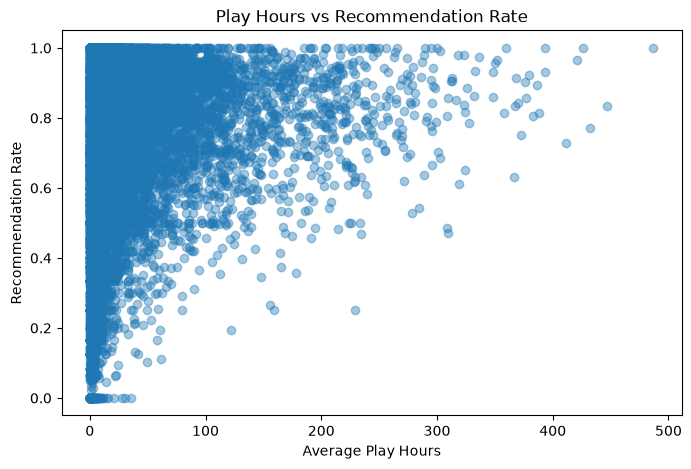

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    games["avg_hours"],
    games["recommend_rate"],
    alpha=0.4
)

plt.xlabel("Average Play Hours")
plt.ylabel("Recommendation Rate")
plt.title("Play Hours vs Recommendation Rate")

plt.show()

Rating과 추천 비율

In [9]:
rating_analysis = (
    games.groupby("rating")
    .agg(
        game_count=("app_id", "count"),
        avg_recommend_rate=("recommend_rate", "mean"),
        avg_hours=("avg_hours", "mean")
    )
    .sort_values(
        "avg_recommend_rate",
        ascending=False
    )
)

print(rating_analysis)

                         game_count  avg_recommend_rate  avg_hours
rating                                                            
Overwhelmingly Positive        1110            0.875495  34.956353
Very Positive                 13139            0.709081  23.932187
Mostly Positive                8738            0.581531  17.725252
Positive                      13502            0.550641   8.411132
Mixed                         12157            0.458441  13.486855
Mostly Negative                1849            0.263526   6.386599
Negative                        303            0.162494   2.629042
Very Negative                    60            0.105286   6.351962
Overwhelmingly Negative          14            0.073740   9.793358
